In [1]:
import sys
from pathlib import Path

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.data_loader import load_application_train
from src.features.data_preparation import prepare_train_validation_data
from src.models.calibration import load_calibrated_model
from src.models.shap_explainability import (
    calculate_feature_importance,
    explain_prediction,
    plot_global_importance,
)

print("SHAP NOTEBOOK SETUP OK")

SHAP NOTEBOOK SETUP OK


In [2]:
df = load_application_train()

X_train, X_valid, y_train, y_valid, preprocessor = prepare_train_validation_data(df)

X_sample = X_valid.iloc[:1000]

X_transformed = preprocessor.fit(X_train).transform(X_sample)

feature_names = preprocessor.get_feature_names_out()

print("VALIDATION SAMPLE:", X_sample.shape)
print("TRANSFORMED SAMPLE:", X_transformed.shape)
print("FEATURE COUNT:", len(feature_names))

VALIDATION SAMPLE: (1000, 132)
TRANSFORMED SAMPLE: (1000, 256)
FEATURE COUNT: 256


In [3]:
model = load_calibrated_model()

lgbm = model.estimator.named_steps["classifier"]

explainer = shap.TreeExplainer(lgbm)

shap_values = explainer.shap_values(X_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP VALUES:", shap_values.shape)

SHAP VALUES: (1000, 256)


D:\credit-risk-intelligence1\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [4]:
importance = calculate_feature_importance(
    shap_values,
    feature_names,
)

top_20 = importance[:20]

for rank, (feature, value) in enumerate(top_20, start=1):
    print(f"{rank:2}. {feature}: {value:.6f}")

 1. numeric__EXT_SOURCE_3: 0.359748
 2. numeric__EXT_SOURCE_2: 0.315545
 3. numeric__EXT_SOURCE_1: 0.154056
 4. numeric__CREDIT_GOODS_RATIO: 0.117354
 5. numeric__AMT_GOODS_PRICE: 0.091535
 6. categorical__CODE_GENDER_F: 0.074211
 7. numeric__AMT_ANNUITY: 0.071688
 8. categorical__NAME_EDUCATION_TYPE_Higher education: 0.071320
 9. numeric__DAYS_ID_PUBLISH: 0.052927
10. categorical__NAME_FAMILY_STATUS_Married: 0.045106
11. numeric__DAYS_EMPLOYED_CLEAN: 0.044242
12. numeric__OWN_CAR_AGE: 0.042889
13. categorical__FLAG_OWN_CAR_N: 0.042632
14. numeric__DAYS_BIRTH: 0.041999
15. numeric__EMPLOYMENT_AGE_RATIO: 0.038659
16. categorical__CODE_GENDER_M: 0.037475
17. numeric__DAYS_LAST_PHONE_CHANGE: 0.035536
18. numeric__AMT_REQ_CREDIT_BUREAU_QRT: 0.034634
19. numeric__FLAG_DOCUMENT_3: 0.034208
20. numeric__AGE_YEARS: 0.030605


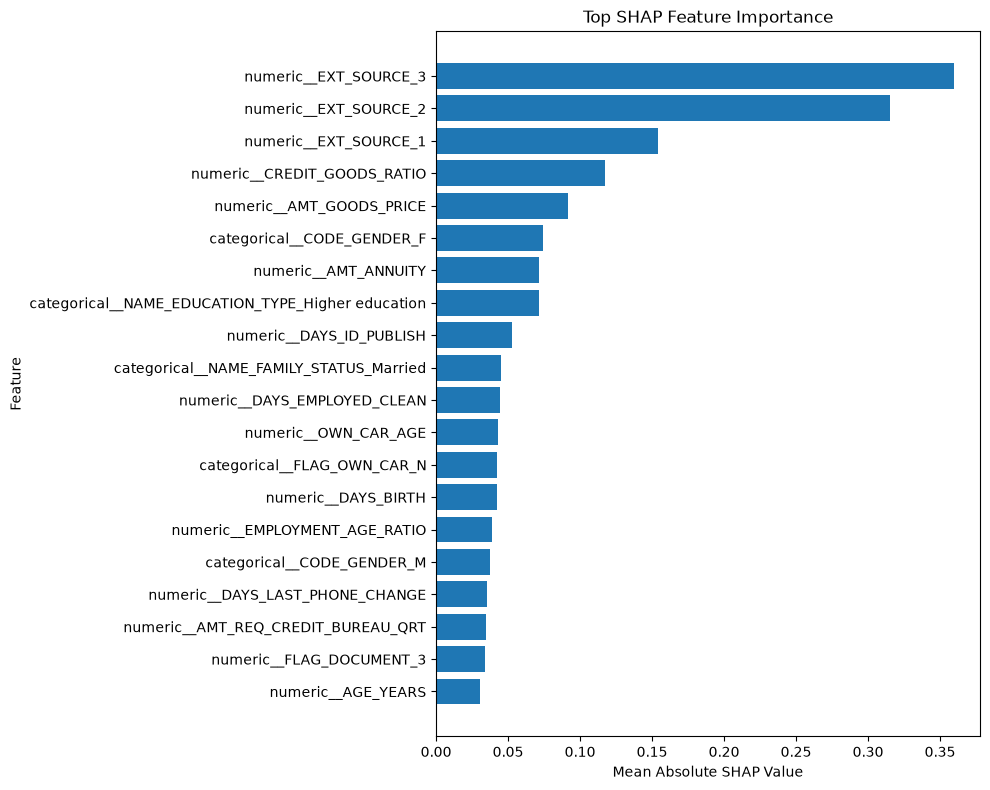

In [5]:
plot_global_importance(
    shap_values,
    feature_names,
    top_n=20,
)

In [6]:
explanation = explain_prediction(
    shap_values,
    feature_names,
    row_index=0,
    top_n=10,
)

print("POSITIVE RISK CONTRIBUTORS:")
for feature, value in explanation["positive"]:
    print(f"{feature}: +{value:.6f}")

print("\nNEGATIVE RISK CONTRIBUTORS:")
for feature, value in explanation["negative"]:
    print(f"{feature}: {value:.6f}")

POSITIVE RISK CONTRIBUTORS:
numeric__EXT_SOURCE_3: +0.179328
numeric__EMPLOYMENT_AGE_RATIO: +0.121418
numeric__EXT_SOURCE_1: +0.108799
numeric__DAYS_EMPLOYED_CLEAN: +0.089952
categorical__CODE_GENDER_F: +0.063236
numeric__DAYS_BIRTH: +0.059643
categorical__CODE_GENDER_M: +0.058344
numeric__AMT_ANNUITY: +0.051752
numeric__OWN_CAR_AGE: +0.038789
numeric__EMPLOYMENT_YEARS: +0.034901

NEGATIVE RISK CONTRIBUTORS:
numeric__AMT_GOODS_PRICE: -0.176913
categorical__NAME_EDUCATION_TYPE_Higher education: -0.125350
numeric__AMT_REQ_CREDIT_BUREAU_QRT: -0.115845
numeric__EXT_SOURCE_2: -0.103760
categorical__NAME_EDUCATION_TYPE_Secondary / secondary special: -0.072468
categorical__FLAG_OWN_CAR_N: -0.052892
numeric__DAYS_ID_PUBLISH: -0.039399
numeric__FLAG_DOCUMENT_3: -0.037318
categorical__NAME_FAMILY_STATUS_Married: -0.033552
numeric__REGION_POPULATION_RELATIVE: -0.026064


# Day 20 — SHAP Visualization & Explainability Summary

## Global SHAP Importance

The global SHAP analysis identifies the features that have the largest average impact on the model predictions.

The most important features include:

* EXT_SOURCE_3
* EXT_SOURCE_2
* EXT_SOURCE_1
* CREDIT_GOODS_RATIO
* AMT_GOODS_PRICE
* CODE_GENDER_F
* AMT_ANNUITY
* NAME_EDUCATION_TYPE_Higher education
* DAYS_ID_PUBLISH
* NAME_FAMILY_STATUS_Married

Mean absolute SHAP values represent feature importance. They do not indicate whether a feature generally increases or decreases default risk.

## Individual Applicant Explanation

For an individual validation applicant, SHAP identifies both positive and negative contributors to the prediction.

Positive SHAP contributions pushed the model toward higher predicted default risk, while negative SHAP contributions pushed the prediction toward lower default risk.

This provides a transparent explanation of why the model assigned a particular risk score to an applicant.

## Business Interpretation

SHAP explainability can help credit-risk analysts understand model decisions at both:

1. **Portfolio level** — which features are generally important.
2. **Applicant level** — why a specific applicant received a particular prediction.

SHAP values explain model behavior and should not be interpreted as causal effects.
